In [1]:
import torch
from torch import Tensor, nn
from math import ceil
from torch.autograd import Function
import os
from torch.autograd.function import Function
import triton
from copy import deepcopy
import triton.language as tl

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [2]:

def get_cuda_autotune_config():
    return [
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        # Good config for fp8 inputs.
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
        #               num_warps=8),
        # triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
        #               num_warps=8),
        # triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        triton.Config(
            {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        triton.Config(
            {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        # Push Blackwell/B200 TC pipes
        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 256, 'GROUP_SIZE_M': 8},
            num_stages=5, num_warps=16
        ),
    ]




In [3]:
def validate_contiguous(x: Tensor) -> Tensor:
    return x if x.is_contiguous() else x.contiguous()


In [4]:
from torch import nn, Tensor
import torch
from torch.autograd.function import Function
import triton
import triton.language as tl
from math import ceil

import math


@triton.jit()
def _compute_sigma(x):
    return 1 / (1 + tl.exp(-x))

@triton.jit()
def _silu_op_fwd(x):
    return x * _compute_sigma(x)

@triton.jit()
def _silu_op_bwd(x, grad_output):
    sigma = _compute_sigma(x)
    act_prime = sigma * (1 + x * (1 - sigma))
    return grad_output * act_prime


@triton.jit
def _compute_tanh_phi(x):
    # angle = tl.sqrt(2 / math.pi)  * (x + 0.044715 * x * x * x)
    angle = 0.7978845608028654 * (x + 0.044715 * x * x * x)
    exp = tl.exp(2 * angle)
    tanh = (exp - 1) / (exp + 1)
    phi = 0.5 * (1 + tanh)
    return tanh, phi


@triton.jit()
def _gelu_op_fwd(x):
    _, phi = _compute_tanh_phi(x)
    return x * phi


@triton.jit()
def _gelu_op_bwd(x, grad_output):
    tanh, phi = _compute_tanh_phi(x)

    factor = 1 / tl.sqrt(2 * math.pi)
    phi_prime = factor * (1 - tanh * tanh) * (1 + 3 * 0.044715 * x * x)

    derivative = x * phi_prime + phi
    return derivative * grad_output

In [5]:

from math import ceil
import triton
import triton.language as tl
import torch
from torch import nn, Tensor
from torch.autograd import Function

MAP_ACTIVATIONS_FWD = {"gelu": None, "silu": _silu_op_fwd}
MAP_ACTIVATIONS_BWD = {"gelu": None, "silu": _silu_op_bwd}

@triton.jit()
def _activation_fwd(x, activation_name: tl.constexpr):
    if activation_name == "silu":
        return _silu_op_fwd(x)
    elif activation_name == "gelu":
        return _gelu_op_fwd(x)
    else:
        raise NotImplementedError
    # return MAP_ACTIVATIONS_FWD[activation_name](x)


@triton.jit()
def _activation_bwd(x, grad_output, activation_name: tl.constexpr):
    if activation_name == "silu":
        return _silu_op_bwd(x, grad_output)
    elif activation_name == "gelu":
        return _gelu_op_bwd(x, grad_output)
    else:
        raise NotImplementedError

@triton.autotune(
    configs=get_cuda_autotune_config(),
    key=['M', 'N', 'K'],
)
@triton.jit()
def _linear_act_fwd_triton(
    x_ptr,
    w_ptr,
    b_ptr,
    o_ptr,
    M,
    N,
    K,
    stride_xm,
    stride_xk,
    stride_wk,
    stride_wn,
    stride_bn,
    stride_om,
    stride_on,
    activation_name: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    pid = tl.program_id(axis=0)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)

    ### map pid to (pid_m, pid_n)
    pid_m = pid // num_programs_n
    pid_n = pid % num_programs_n

    ### get offsets along M, N, K directions
    offset_m = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offset_n = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offset_k = tl.arange(0, BLOCK_SIZE_K)

    mask_m = offset_m[:, None] < M
    mask_n = offset_n[None, :] < N

    ### get starting pointers for x, w, b
    tile_x_ptr = x_ptr + (offset_m[:, None] * stride_xm + offset_k[None, :] * stride_xk)
    tile_w_ptr = w_ptr + (offset_k[:, None] * stride_wk + offset_n[None, :] * stride_wn)
    tile_b_ptr = b_ptr + offset_n[None, :] * stride_bn

    tile_b = tl.load(tile_b_ptr, mask_n, other=0.0)

    ### frist compute z = x @ W.T + b
    z = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        # mask values depending on k: note that we are not loading all the row
        # up to k * BLOCK_SIZE_K. Since we are advancing the pointers
        # (see tile_x_ptr += ..., tile_w_ptr += ...) we are considering only
        # the portion [k*BLOCK_SIZE_K:(k+1)*BLOCK_SIZE_K].
        mask_k = offset_k < K - k * BLOCK_SIZE_K

        tile_x = tl.load(tile_x_ptr, mask_k[None, :], other=0.0)
        tile_w = tl.load(tile_w_ptr, mask_k[:, None], other=0.0)

        z = tl.dot(tile_x, tile_w, z)

        # advance the pointers along k directions to the next block
        tile_x_ptr += BLOCK_SIZE_K * stride_xk
        tile_w_ptr += BLOCK_SIZE_K * stride_wk

    ### then compute activation + downcast to bfloat16
    # z += tile_b
    # o = z
    o = _activation_fwd(z + tile_b, activation_name)
    # o = o.to(tl.bfloat16)

    tile_o_ptr = o_ptr + offset_m[:, None] * stride_om + offset_n[None, :] * stride_on
    mask_o = mask_m & mask_n
    tl.store(tile_o_ptr, o, mask_o)


def _linear_act_fwd(
    x: Tensor,
    W: Tensor,
    b: Tensor,
    transpose_x: bool = False,
    transpose_W: bool = False,
    activation_name: str = "gelu",
):
    """
    Triton implementation of the following kernel
        z = x @ W.T + b
        out =  f(z)

    IMPORTANT NOTE: the .T operation is done inside tge triton kernel by swapping the
    stride values of W, therefore pass W and not W.T.

    """
    assert x.ndim == 2, "expected A to have ndim=2"
    assert W.ndim == 2, "expected B to have ndim=2"

    if transpose_x:
        M, K = x.shape
        raise NotImplementedError
    else:
        K, M = x.shape
        
    if transpose_W:
        N = W.shape[0]
        assert K == W.shape[1], "dimension mismatch"
        stride_W = (W.stride(1), W.stride(0))
    else:
        N = W.shape[0]
        stride_W = (W.stride(0), W.stride(1))
        assert K == W.shape[0], "dimension mismatch"

    assert b.ndim <= 1, f"b is expected to be either 0D or 1D tensor, got {b.ndim}D"
    # assert b.shape[0] == W.shape[1], "dimension mismatch"

    if b.ndim == 0:
        b = b.view(1, -1)

    # using naive block matmul for now, implement more efficient algo later

    # BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K = (64, 64, 64)  # hard-coded for now
    # GROUP_SIZE_M = 8
    # grid = ((ceil(M / BLOCK_SIZE_M) * ceil(N / BLOCK_SIZE_N)),)

    out = torch.zeros((M, N), device=x.device, dtype=x.dtype)

    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )
    _linear_act_fwd_triton[grid](
        x,
        W,
        b,
        out,
        M,
        N,
        K,
        x.stride(0),
        x.stride(1),
        stride_W[0],
        stride_W[1],
        b.stride(0),
        out.stride(0),
        out.stride(1),
        activation_name,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # GROUP_SIZE_M,
    )
    ...

    return out.to(x.dtype)



16 16 16 triton fwd flops
tensor(0.0150, device='cuda:0', dtype=torch.bfloat16)
16 16 16 torch fwd flops
32 32 32 triton fwd flops
tensor(0.0082, device='cuda:0', dtype=torch.bfloat16)
32 32 32 torch fwd flops
64 64 64 triton fwd flops
tensor(0.0037, device='cuda:0', dtype=torch.bfloat16)
64 64 64 torch fwd flops
128 128 128 triton fwd flops
tensor(0.0035, device='cuda:0', dtype=torch.bfloat16)
128 128 128 torch fwd flops
256 256 256 triton fwd flops
tensor(0.0029, device='cuda:0', dtype=torch.bfloat16)
256 256 256 torch fwd flops
512 512 512 triton fwd flops
tensor(0., device='cuda:0', dtype=torch.bfloat16)
512 512 512 torch fwd flops
1024 1024 1024 triton fwd flops
tensor(0., device='cuda:0', dtype=torch.bfloat16)
1024 1024 1024 torch fwd flops
2048 2048 2048 triton fwd flops
tensor(0., device='cuda:0', dtype=torch.bfloat16)
2048 2048 2048 torch fwd flops
4096 4096 4096 triton fwd flops
tensor(0., device='cuda:0', dtype=torch.bfloat16)
4096 4096 4096 torch fwd flops
8192 8192 8192 tr

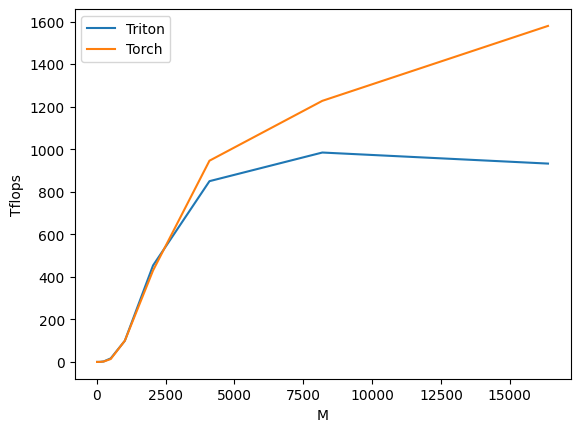

softmax - flops - fwd:
          M        N        K      Triton        Torch
0      16.0     16.0     16.0    0.000551     0.000528
1      32.0     32.0     32.0    0.004433     0.004214
2      64.0     64.0     64.0    0.035695     0.029843
3     128.0    128.0    128.0    0.287439     0.239620
4     256.0    256.0    256.0    2.193674     1.826787
5     512.0    512.0    512.0   16.660592    13.751817
6    1024.0   1024.0   1024.0   99.420537    99.715994
7    2048.0   2048.0   2048.0  453.438251   429.840614
8    4096.0   4096.0   4096.0  849.647326   945.819732
9    8192.0   8192.0   8192.0  984.237683  1227.177314
10  16384.0  16384.0  16384.0  932.266683  1579.340606
16 16 16 triton fwd memory
tensor(0.0141, device='cuda:0', dtype=torch.bfloat16)
16 16 16 torch fwd memory
32 32 32 triton fwd memory
tensor(0.0081, device='cuda:0', dtype=torch.bfloat16)
32 32 32 torch fwd memory
64 64 64 triton fwd memory
tensor(0.0041, device='cuda:0', dtype=torch.bfloat16)
64 64 64 torch fwd mem

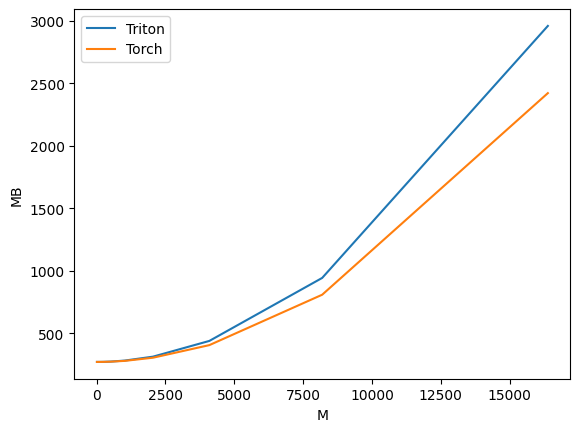

softmax - memory - fwd:
          M        N        K       Triton        Torch
0      16.0     16.0     16.0   272.640512   272.640000
1      32.0     32.0     32.0   272.648192   272.646144
2      64.0     64.0     64.0   272.678912   272.670720
3     128.0    128.0    128.0   272.801792   272.769024
4     256.0    256.0    256.0   273.293312   273.162240
5     512.0    512.0    512.0   275.259904   274.735616
6    1024.0   1024.0   1024.0   283.387392   281.028096
7    2048.0   2048.0   2048.0   314.584576   306.195968
8    4096.0   4096.0   4096.0   440.417792   406.863360
9    8192.0   8192.0   8192.0   943.742464   809.524736
10  16384.0  16384.0  16384.0  2957.024768  2420.153856


In [10]:
def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

base_benchmark_kwargs = {
        "x_names":['M', 'N', "K"],  # argument names to use as an x-axis for the plot
        "x_vals":[int(2**i) for i in range(4, 15)],  # different possible values for `x_name`
        "line_arg":'provider',  # argument name whose value corresponds to a different line in the plot
        "line_vals":['triton', 'torch'],  # possible values for `line_arg``
        "line_names":["Triton", "Torch"],  # label name for the lines
        # "styles":[('blue', '-'), ('green', '-')],  # line styles
        "ylabel":"GB/s",  # label name for the y-axis
        "plot_name":"softmax",  # name for the plot. Used also as a file name for saving the plot.
        "args":{}, #{'K': 256} # values for function arguments not in `x_names` and `y_name`
}

from copy import deepcopy
configs = []
for bench_kind in ['flops', 'memory']:
    for mode in ['fwd']: #, 'bwd']:
        _kwargs = deepcopy(base_benchmark_kwargs)
        _kwargs['args'].update({"mode" : mode})
        _kwargs['args'].update({"bench_kind" : bench_kind})
        _kwargs['ylabel'] = 'Tflops' if bench_kind == 'flops' else 'MB'
        _kwargs['plot_name'] += f' - {bench_kind} - {mode}'
        configs.append(triton.testing.Benchmark(**_kwargs))


def fwd(x, W, b, provider):
    if provider == "torch":
        return torch.nn.functional.silu(x @ W.T + b)
    elif provider == 'triton':
        return _linear_act_fwd(x, W, b, transpose_W=True)
    else:
        raise ValueError

def bwd(x, provider):
    x.requires_grad = True
    out = fwd(x, provider)
    loss = out.sum()
    loss.backward()

MAP_FWD_BKW = {
    "fwd" : fwd,
    # "bwd" : bwd,
}

def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

# torch.set_float32_matmul_precision("medium")
# torch.backends.cudnn.conv.fp32_precision = 'tf32'


def benchmark_kernel():

    # for c in configs:
    #     print(c.__dict__)

    @triton.testing.perf_report(configs)
    def benchmark(M, N, K, provider, mode, bench_kind):
        
        print(M, N, K, provider, mode, bench_kind)
        DTYPE = torch.bfloat16
        
        x = torch.rand(M, K, dtype=DTYPE).to(DEVICE) / M / K
        W = torch.rand(K, N, dtype=DTYPE).to(DEVICE) / K / N
        b = torch.rand(N, dtype=DTYPE).to(DEVICE) / N

        W = W.T

        stream = getattr(torch, DEVICE.type).Stream()
        getattr(torch, DEVICE.type).set_stream(stream)

        if provider == 'triton' and mode =="fwd":
            out_triton = MAP_FWD_BKW[mode](x, W, b, 'triton')
            out_torch = MAP_FWD_BKW[mode](x, W, b, 'torch')
            triton.testing.assert_close(out_triton, out_torch, atol=1e-2)
            print((out_triton - out_torch).norm()/out_torch.norm())

        quantiles = [0.5, 0.2, 0.8]

        if bench_kind == "flops":
            ms, min_ms, max_ms = triton.testing.do_bench(lambda: MAP_FWD_BKW[mode](x, W, b, provider), quantiles=quantiles)
            # gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
            perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
            return perf(ms)
        elif bench_kind == "memory":
            mem_mb = measure_memory(MAP_FWD_BKW[mode], x, W, b, provider)
            return mem_mb
        raise ValueError(f"bench_kind must be either 'flops' or 'memory', got {bench_kind}")

    result_dfs = benchmark.run(show_plots=True, print_data=True)
    # for df, config in zip(result_dfs, configs):
    #     df.plot(x='N', ylabel = config.ylabel, title=config.plot_name, legend=True)

    return result_dfs

result_dfs = benchmark_kernel()

In [11]:

@triton.jit()
def _linear_act_fwd_triton(
    x_ptr,
    w_ptr,
    b_ptr,
    o_ptr,
    M,
    N,
    K,
    stride_xm,
    stride_xk,
    stride_wk,
    stride_wn,
    stride_bn,
    stride_om,
    stride_on,
    # activation_name,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    pid = tl.program_id(axis=0)
    num_programs_n = tl.cdiv(N, BLOCK_SIZE_N)

    ### map pid to (pid_m, pid_n)
    pid_m = pid // num_programs_n
    pid_n = pid % num_programs_n

    ### get offsets along M, N, K directions
    offset_m = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offset_n = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offset_k = tl.arange(0, BLOCK_SIZE_K)

    mask_m = offset_m[:, None] < M
    mask_n = offset_n[None, :] < N

    ### get starting pointers for x, w, b
    tile_x_ptr = x_ptr + (offset_m[:, None] * stride_xm + offset_k[None, :] * stride_xk)
    tile_w_ptr = w_ptr + (offset_k[:, None] * stride_wk + offset_n[None, :] * stride_wn)
    tile_b_ptr = b_ptr + offset_n[None, :] * stride_bn

    tile_b = tl.load(tile_b_ptr, mask_n, other=0.0)

    ### frist compute z = x @ W.T + b
    z = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        # mask values depending on k: note that we are not loading all the row
        # up to k * BLOCK_SIZE_K. Since we are advancing the pointers
        # (see tile_x_ptr += ..., tile_w_ptr += ...) we are considering only
        # the portion [k*BLOCK_SIZE_K:(k+1)*BLOCK_SIZE_K].
        mask_k = offset_k < K - k * BLOCK_SIZE_K

        tile_x = tl.load(tile_x_ptr, mask_k[None, :], other=0.0)
        tile_w = tl.load(tile_w_ptr, mask_k[:, None], other=0.0)

        z = tl.dot(tile_x, tile_w, z)

        # advance the pointers along k directions to the next block
        tile_x_ptr += BLOCK_SIZE_K * stride_xk
        tile_w_ptr += BLOCK_SIZE_K * stride_wk

    ### then compute activation + downcast to bfloat16
    z += tile_b
    # o = z
    o = _gelu_op_fwd(z)
    # o = o.to(tl.bfloat16)

    tile_o_ptr = o_ptr + offset_m[:, None] * stride_om + offset_n[None, :] * stride_on
    mask_o = mask_m & mask_n
    tl.store(tile_o_ptr, o, mask_o)


def _linear_act_fwd(
    x: Tensor,
    W: Tensor,
    b: Tensor,
    transpose_x: bool = False,
    transpose_W: bool = False,
    activation_name: str = "gelu",
):
    """
    Triton implementation of the following kernel
        z = x @ W.T + b
        out =  f(z)

    IMPORTANT NOTE: the .T operation is done inside tge triton kernel by swapping the
    stride values of W, therefore pass W and not W.T.

    """
    assert x.ndim == 2, "expected A to have ndim=2"
    assert W.ndim == 2, "expected B to have ndim=2"

    if transpose_x:
        M, K = x.shape
        raise NotImplementedError
    else:
        K, M = x.shape
        
    if transpose_W:
        N = W.shape[0]
        assert K == W.shape[1], "dimension mismatch"
        stride_W = (W.stride(1), W.stride(0))
    else:
        N = W.shape[0]
        stride_W = (W.stride(0), W.stride(1))
        assert K == W.shape[0], "dimension mismatch"

    assert b.ndim <= 1, f"b is expected to be either 0D or 1D tensor, got {b.ndim}D"
    # assert b.shape[0] == W.shape[1], "dimension mismatch"

    if b.ndim == 0:
        b = b.view(1, -1)

    # using naive block matmul for now, implement more efficient algo later

    BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K = (64, 64, 64)  # hard-coded for now
    GROUP_SIZE_M = 8

    grid = ((ceil(M / BLOCK_SIZE_M) * ceil(N / BLOCK_SIZE_N)),)

    out = torch.zeros((M, N), device=x.device, dtype=x.dtype)

    _linear_act_fwd_triton[grid](
        x,
        W,
        b,
        out,
        M,
        N,
        K,
        x.stride(0),
        x.stride(1),
        stride_W[0],
        stride_W[1],
        b.stride(0),
        out.stride(0),
        out.stride(1),
        # activation_name,
        BLOCK_SIZE_M,
        BLOCK_SIZE_N,
        BLOCK_SIZE_K,
        GROUP_SIZE_M,
    )
    ...

    return out



16 16 16 triton fwd flops
16 16 16 torch fwd flops
32 32 32 triton fwd flops
32 32 32 torch fwd flops
64 64 64 triton fwd flops
64 64 64 torch fwd flops
128 128 128 triton fwd flops
128 128 128 torch fwd flops
256 256 256 triton fwd flops
256 256 256 torch fwd flops
512 512 512 triton fwd flops
512 512 512 torch fwd flops
1024 1024 1024 triton fwd flops
1024 1024 1024 torch fwd flops
2048 2048 2048 triton fwd flops
2048 2048 2048 torch fwd flops
4096 4096 4096 triton fwd flops
4096 4096 4096 torch fwd flops
8192 8192 8192 triton fwd flops
8192 8192 8192 torch fwd flops
16384 16384 16384 triton fwd flops
16384 16384 16384 torch fwd flops


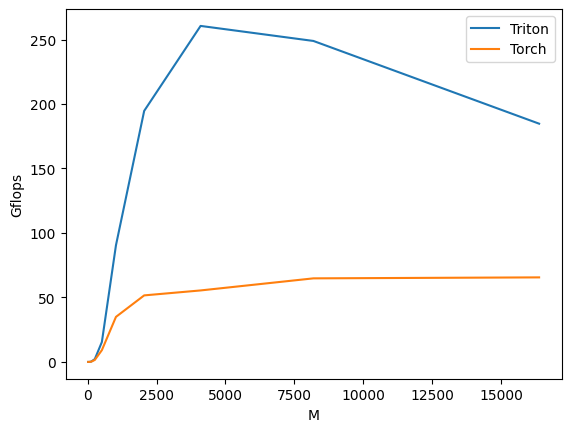

softmax - flops - fwd:
          M        N        K      Triton      Torch
0      16.0     16.0     16.0    0.000619   0.000483
1      32.0     32.0     32.0    0.005044   0.003761
2      64.0     64.0     64.0    0.039794   0.029118
3     128.0    128.0    128.0    0.286913   0.214775
4     256.0    256.0    256.0    2.192236   1.536321
5     512.0    512.0    512.0   15.410523   9.103244
6    1024.0   1024.0   1024.0   90.489295  34.934783
7    2048.0   2048.0   2048.0  194.661692  51.593911
8    4096.0   4096.0   4096.0  260.557029  55.435898
9    8192.0   8192.0   8192.0  248.899940  64.803433
10  16384.0  16384.0  16384.0  184.747651  65.557010
16 16 16 triton fwd memory
16 16 16 torch fwd memory
32 32 32 triton fwd memory
32 32 32 torch fwd memory
64 64 64 triton fwd memory
64 64 64 torch fwd memory
128 128 128 triton fwd memory
128 128 128 torch fwd memory
256 256 256 triton fwd memory
256 256 256 torch fwd memory
512 512 512 triton fwd memory
512 512 512 torch fwd memory
1024 

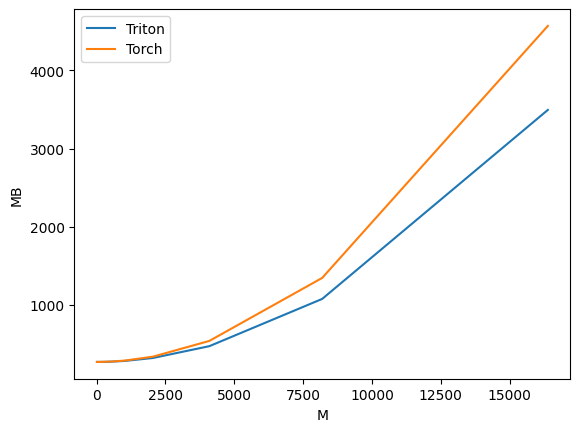

softmax - memory - fwd:
          M        N        K       Triton        Torch
0      16.0     16.0     16.0   272.635904   272.636928
1      32.0     32.0     32.0   272.645120   272.649216
2      64.0     64.0     64.0   272.681984   272.698368
3     128.0    128.0    128.0   272.829440   272.894976
4     256.0    256.0    256.0   273.419776   273.681920
5     512.0    512.0    512.0   275.780096   276.828672
6    1024.0   1024.0   1024.0   285.219328   289.413632
7    2048.0   2048.0   2048.0   322.972160   339.749376
8    4096.0   4096.0   4096.0   473.975296   541.084160
9    8192.0   8192.0   8192.0  1077.971456  1346.406912
10  16384.0  16384.0  16384.0  3493.923328  4567.665152


In [13]:
def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

base_benchmark_kwargs = {
        "x_names":['M', 'N', "K"],  # argument names to use as an x-axis for the plot
        "x_vals":[int(2**i) for i in range(4, 15)],  # different possible values for `x_name`
        "line_arg":'provider',  # argument name whose value corresponds to a different line in the plot
        "line_vals":['triton', 'torch'],  # possible values for `line_arg``
        "line_names":["Triton", "Torch"],  # label name for the lines
        # "styles":[('blue', '-'), ('green', '-')],  # line styles
        "ylabel":"GB/s",  # label name for the y-axis
        "plot_name":"softmax",  # name for the plot. Used also as a file name for saving the plot.
        "args":{}, #{'K': 256} # values for function arguments not in `x_names` and `y_name`
}

from copy import deepcopy
configs = []
for bench_kind in ['flops', 'memory']:
    for mode in ['fwd']: #, 'bwd']:
        _kwargs = deepcopy(base_benchmark_kwargs)
        _kwargs['args'].update({"mode" : mode})
        _kwargs['args'].update({"bench_kind" : bench_kind})
        _kwargs['ylabel'] = 'Gflops' if bench_kind == 'flops' else 'MB'
        _kwargs['plot_name'] += f' - {bench_kind} - {mode}'
        configs.append(triton.testing.Benchmark(**_kwargs))


def fwd(x, W, b, provider):
    if provider == "torch":
        return torch.nn.functional.gelu(x @ W.T + b)
    elif provider == 'triton':
        return _linear_act_fwd(x, W, b, transpose_W=True)
    else:
        raise ValueError

def bwd(x, provider):
    x.requires_grad = True
    out = fwd(x, provider)
    loss = out.sum()
    loss.backward()

MAP_FWD_BKW = {
    "fwd" : fwd,
    # "bwd" : bwd,
}

def measure_memory(f, *args, **kwargs):
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.empty_cache()

    f(*args, **kwargs)  # run your function once

    torch.cuda.synchronize()
    peak = torch.cuda.max_memory_allocated() / 1e6  # MB
    return peak

def benchmark_kernel():

    # for c in configs:
    #     print(c.__dict__)

    @triton.testing.perf_report(configs)
    def benchmark(M, N, K, provider, mode, bench_kind):
        
        print(M, N, K, provider, mode, bench_kind)
        
        x = torch.rand(M, K).to(DEVICE) / M / K
        W = torch.rand(N, K).to(DEVICE) / K / N
        b = torch.rand(N).to(DEVICE) / N
    
        stream = getattr(torch, DEVICE.type).Stream()
        getattr(torch, DEVICE.type).set_stream(stream)
        if bench_kind == "flops":
            ms = triton.testing.do_bench(lambda: MAP_FWD_BKW[mode](x, W, b, provider))
            perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
            # gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
            return perf(ms)
        elif bench_kind == "memory":
            mem_mb = measure_memory(MAP_FWD_BKW[mode], x, W, b, provider)
            return mem_mb
        raise ValueError(f"bench_kind must be either 'timing' or 'memory', got {bench_kind}")

    result_dfs = benchmark.run(show_plots=True, print_data=True, return_df=True)
    # for df, config in zip(result_dfs, configs):
    #     df.plot(x='N', ylabel = config.ylabel, title=config.plot_name, legend=True)

    return result_dfs

result_dfs = benchmark_kernel()